# documentation.ipynb

This Jupyter notebook provides documentation for the roadside module which provides Python code which detects coconut rhinoceros beetle damages in images.

In [1]:
# import roadside as rs
import pandas as pd
import sqlite3
from icecream import ic
from shapely.geometry import Polygon
from shapely import wkt
from graphviz import Digraph
import graphviz
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [99]:
def get_bbox_shapely(wkt_string):
    """Returns (minx, miny, maxx, maxy) using Shapely."""
    poly = wkt.loads(wkt_string)
    return poly.bounds

# Example usage
wkt_input = "POLYGON ((30 10, 40 40, 20 40, 10 20, 30 10))"
# print(get_bbox_shapely(wkt_input)) 
# Output: (10.0, 10.0, 40.0, 40.0)

# img = np.zeros((500, 500, 3), dtype=uint8)
# cv2.drawContours()

poly_str = "POLYGON ((30 10, 40 40, 20 40, 10 20, 30 10))"
poly.wkt = Polygon(poly_str)
x = wkt.loads(ploy_wkt)
x.is_closed

# ic(get_bbox_shapely(wkt_input))


ValueError: could not convert string to float: 'P'

In [ ]:
def add_round_label(
    image,
    center = (100, 100),
    radius = 20,
    text = "969",
    font = cv2.FONT_HERSHEY_SIMPLEX,
    font_scale = 0.5,
    font_thickness = 1,
    bg_color = (255, 255, 255),
    fg_color = (0, 0, 0)):
    """ 
    Adds a labelled circle at a point on an image.
    """
    
    # Draw white filled circle
    cv2.circle(image, center, radius, bg_color, -1)

    # Add text centered in circle
    text_size = cv2.getTextSize(text, font, font_scale, font_thickness)[0]
    text_x = center[0] - text_size[0] // 2
    text_y = center[1] + text_size[1] // 2
    cv2.putText(image, text, (text_x, text_y), font, 
                font_scale, fg_color, font_thickness, cv2.LINE_AA)
    
    return image

# Example usage:

# img = np.zeros((500, 500, 3), dtype="uint8") # create black 
# img = add_round_label(img, center=(200, 200))
# plt.imshow(img)
# plt.show()

example_images/08hs-palms-03-zglw-superJumbo.webp


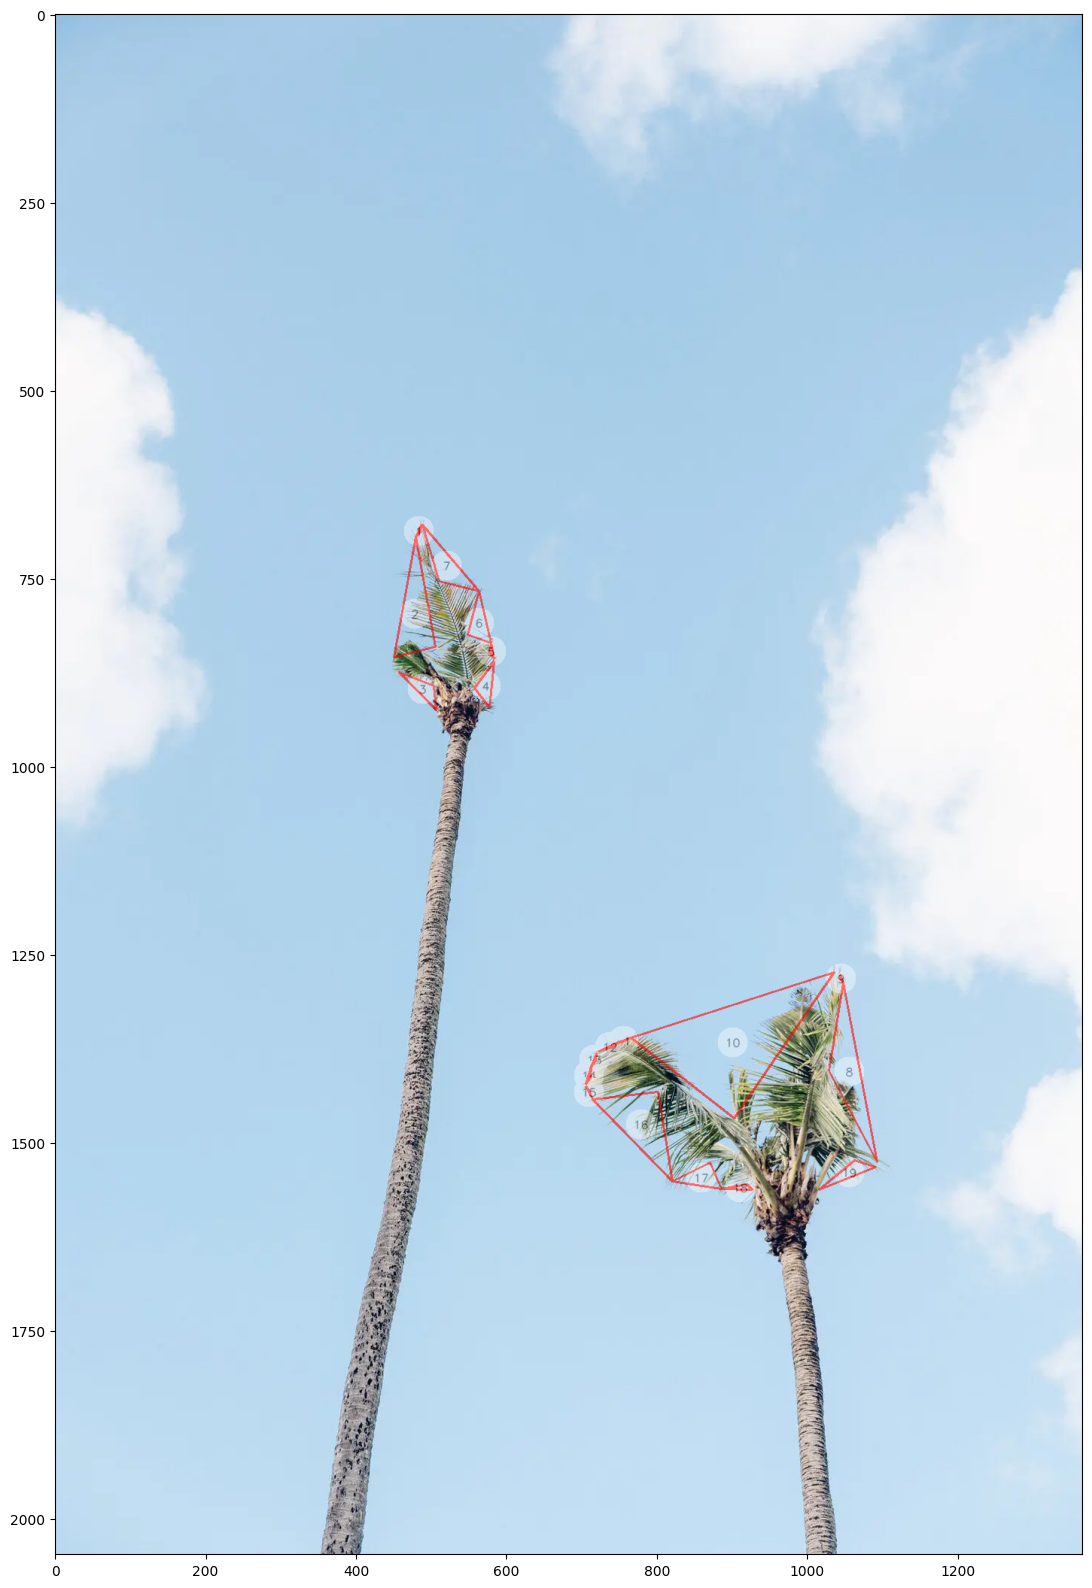

In [ ]:
# In this cell we annotate a selected image to visualize convexity hill defects in coconut hull crowns.

selected_image_id = 1

# get data
sql = f''' 
SELECT *
FROM images, detections, vcuts
WHERE
    images.image_id={selected_image_id} AND
	images.image_id=detections.image_id AND
	detections.detection_id=vcuts.detection_id
'''
df = pd.read_sql(sql, sqlite3.Connection('test.db'))
print(df.loc[0]['image_path'])

# load image
img = cv2.imread(df.loc[0]['image_path'])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

overlay = img.copy()
for r in df.itertuples():
    coords = [(r.start_x, r.start_y), (r.far_x, r.far_y), (r.end_x, r.end_y), (r.start_x, r.start_y)]
    triangle = Polygon(coords)
    centroid = triangle.centroid
    coords = np.array(triangle.exterior.coords, dtype=np.int32)
    cv2.polylines(img, [coords], isClosed=True, color=(255, 0, 0), thickness=2)
    
    # add defect label to overlay
    overlay = add_round_label(overlay, text=str(r.vcut_id), center=(int(centroid.x), int(centroid.y)))

# add overlay to img semitransparently
alpha = 0.4
labelled_image = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)

# display labelled_image
fig, (ax1) = plt.subplots(1, 1, figsize=(20, 20)) 
ax1.imshow(labelled_image)  
plt.show()  


In [3]:
def draw_sqlite_schema(db_path):
    dot = Digraph(comment='Database Schema', graph_attr={'rankdir':'RL'})
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    # Get all table names
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = [t[0] for t in cursor.fetchall() if t[0] != 'sqlite_sequence']
    
    for table in tables:
    
        # Get column details
        cursor.execute(f"PRAGMA table_info({table})")
        columns = cursor.fetchall()
        
        # Build an HTML-like label for the table node
        label = f'<<TABLE BORDER="0" CELLBORDER="1" CELLSPACING="0"><TR><TD COLSPAN="2"><B>{table}</B></TD></TR>'
        for col in columns:
            label += f'<TR><TD ALIGN="LEFT">{col[1]}</TD><TD ALIGN="LEFT">{col[2]}</TD></TR>'
        label += '</TABLE>>'
        
        dot.node(table, label=label, shape='none')
        
        # Check for Foreign Keys to draw relationships
        cursor.execute(f"PRAGMA foreign_key_list({table})")
        for fk in cursor.fetchall():
            dot.edge(table, fk[2], label='FK')
            
    conn.close()
    return dot

# Usage
# draw_sqlite_schema('test.db')

# Database

This project uses an SQLite database for persistent storage of data extracted from images.
The database contains three tables: `images`, `detections` and `vcuts`. 

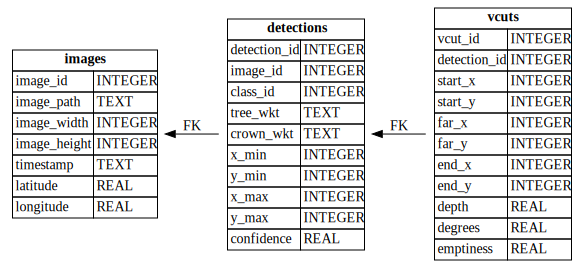

In [4]:
# rs.create_db(db_file='caca.db', overwrite=True)
draw_sqlite_schema('test.db')

## Images table

Each record in the `images` contains data for an image.

`timestamp`, `latitude` and `longitude` are extracted from EXIF metadata embedded in the image, when available.

I am considering storing `latitude` and `longitude` as WKT.

field | description
----- | -----------
image_id | image serial number
image_path | image file location
image_width | width of image in pixels
image_height | image height in pixels
timestamp | date and time when the image was recorded
latitude | location of the camera when the image was recorded; in decimal degrees
longitude | location of the camera when the image was recorded; in decimal degrees

## Detections table

Each record in the `detections` contains data for a 'coconut palm tree' detected by the SAM3 model.

I am considering removing the bounding box coordinates because they can be easily calculated from `tree_wkt`.

field | description
----- | -----------
detection_id | detection serial number
image_id | a foreign key linking the `detection` record to an `image` record
class_id | currently there is only one class (0 = 'coconut palm tree')
tree_wkt | a polygon surrounding the detected tree
crown _wkt | a polygon surrounding the crown of the detected tree
xmin | detection bounding box in pixels
ymin | detection bounding box in pixels
xmax | detection bounding box in pixels
ymax | detection bounding box in pixels
confidence | confidence level for the detection provided by the SAM3 object detector

## Vcuts table

Each record in the `vcuts` contains data for a v-shaped cut in the crown of a coconut palm detected as a convexity defect.

I am considering storing the 3 coordinates for the convexity defect as `triangle_wkt`.

field | description
----- | -----------
vcut_id | vcut serial number
detection_id | a foreign key linking the `vcut` record to a `detection` record
start_x | coordinates for convexity defect in pixels
start_y | coordinates for convexity defect in pixels
far_x | coordinates for convexity defect in pixels
far_y | coordinates for convexity defect in pixels
end_x | coordinates for convexity defect in pixels
end_y | coordinates for convexity defect in pixels
depth | distance from the 'far' point to the convex hull in pixels
degrees | angle of the vcut in degrees
emptiness | proportion of the vcut unoccupied by foliage

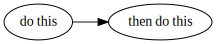

In [5]:
dot = '''
digraph {
    rankdir=LR
    a[label="do this"]
    b[label="then do this"]
    a -> b
}
'''
graphviz.Source(dot)

## Pseudocode for image processing workflow

```
create an empty database with images, detections and vcuts tables
FOR EACH image in image list
    IF image contains exif metadata THEN
        extract timestamp and GPS coordinates
    detect coconut palms using SAM3
    FOR EACH detection in detections list
        find vcuts using the convexity defects method
    NEXT detection
    append data to images, detections, and vcuts tables
NEXT image
```

I have three input variables which are real numbers and one boolean output. How can I develop an equation which will use the 3 inputs to estimate the probability that the output is true?

To estimate the probability of a binary outcome (Boolean) based on continuous real-valued inputs, the standard mathematical approach is **Logistic Regression**. 

Unlike linear regression, which can predict values outside the range of 0 and 1, logistic regression uses a specific function to ensure the output always represents a valid probability.

---

## 1. The Logistic (Sigmoid) Function
To map any real number to a value between 0 and 1, we use the **Sigmoid function**, denoted as $\sigma(z)$. The equation is:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$



[Image of the Sigmoid function graph]


As $z$ becomes a very large positive number, $\sigma(z)$ approaches **1**. As $z$ becomes a very large negative number, $\sigma(z)$ approaches **0**.

---

## 2. Developing the Equation
To use your three input variables ($x_1, x_2, x_3$), you first create a linear combination of these inputs. This is called the **logit**.

### Step A: The Linear Equation
You assign a **weight** ($w$) to each input and add a **bias** term ($b$):

$$z = w_1x_1 + w_2x_2 + w_3x_3 + b$$

### Step B: The Probability Equation
You then wrap that linear equation inside the Sigmoid function to get your probability ($P$):

$$P(\text{Output} = \text{True}) = \frac{1}{1 + e^{-(w_1x_1 + w_2x_2 + w_3x_3 + b)}}$$

---

## 3. How to Find the Weights
The equation itself is the "skeleton." To make it work for your specific data, you need to find the values for $w_1, w_2, w_3,$ and $b$. This is typically done through a process called **Maximum Likelihood Estimation (MLE)**.

1.  **Collect Data:** You need a dataset of past inputs and their known Boolean outcomes.
2.  **Training:** You use an algorithm (like Gradient Descent) to adjust the weights until the equation accurately predicts the outcomes in your dataset.
3.  **Implementation:** Once trained, you can plug any three new real numbers into the equation to get a probability score.

---

## Alternative Approaches
If the relationship between your variables is highly complex or non-linear, you might consider:

* **Decision Trees/Random Forests:** These don't use a single "equation" in the classical sense but are excellent at outputting class probabilities.
* **Neural Networks:** Essentially a "stack" of many logistic regression equations (neurons) working together to find patterns.

For most standard applications, however, the **Logistic Regression** equation provided above is the most transparent and efficient starting point.

To find these weights, the most common and robust approach in Python is using the **Scikit-Learn** library. It handles the optimization (Maximum Likelihood Estimation) for you automatically.

Here is a script that demonstrates how to generate some sample data, train the model, and extract the coefficients ($w_1, w_2, w_3$) and the intercept ($b$).

```python
import numpy as np
from sklearn.linear_model import LogisticRegression

# 1. Create some sample data
# Let's assume 100 rows of data with 3 features each
np.random.seed(42)
X = np.random.randn(100, 3)  # Three input variables (real numbers)

# Generate a Boolean output (True/False) based on a hidden relationship
# In a real scenario, this would be your actual historical data
y = (X[:, 0] * 1.5 + X[:, 1] * -2.0 + X[:, 2] * 0.5 + 0.5 > 0)

# 2. Initialize and train the Logistic Regression model
model = LogisticRegression()
model.fit(X, y)

# 3. Extract the weights (coefficients) and the bias (intercept)
weights = model.coef_[0]
bias = model.intercept_[0]

print("--- Model Parameters ---")
print(f"Weight 1 (w1): {weights[0]:.4f}")
print(f"Weight 2 (w2): {weights[1]:.4f}")
print(f"Weight 3 (w3): {weights[2]:.4f}")
print(f"Bias (b):      {bias:.4f}")

# 4. Use the model to estimate probability for new inputs
new_input = np.array([[1.2, -0.5, 2.1]])
probability = model.predict_proba(new_input)[0][1]

print("\n--- Prediction ---")
print(f"For input {new_input[0]}, the probability of True is: {probability:.2%}")
```

### Key Components of the Script:

* **`model.fit(X, y)`**: This is where the "learning" happens. The algorithm iterates through your data to find the values of $w$ and $b$ that minimize prediction error.
* **`model.coef_`**: These are your **weights**. A positive weight means that as that input increases, the probability of the output being "True" also increases.
* **`model.intercept_`**: This is your **bias**. It represents the "baseline" log-odds when all your input variables are zero.
* **`model.predict_proba()`**: This returns two values: the probability of the outcome being False (0) and the probability of it being True (1). We select the second value `[0][1]` to get the "True" probability.

### Mathematical Verification
If you want to verify the result manually using the weights from the script, you would plug them back into the Sigmoid formula from before:

$$P = \frac{1}{1 + e^{-(w_1x_1 + w_2x_2 + w_3x_3 + b)}}$$